## Lab 4 - Amanda Chang
### Pre-Lab: Inductor Assembly & Calculations


$A_{eff} = A_{min} = 59.1 mm^2 = 5.91e^{-5} m^2$

$\phi_{max} = B_{max} * A_{eff}$

$N_{min} = \frac{L*I_{pk}}{\phi_{max}}$

Using these equations, we calculate the minimum number of turns in our custom inductor given the effective area from the UC2844 datasheet, and the B_max and I_pk values from the pre-lab requirements.

In [1]:
import math
import numpy as np
# Given vals & requirements
L = 20e-6 # in H
I_PK = 6 # in A
B_MAX = 200e-3 # in T
A_RMS = 10 # in A_rms/mm^2
u_0 = 4*math.pi*1e-7 # permeability of free space in H/m
R_SH = 0.05
Vg = 18

A_MIN = 5.91e-5 # in m^2
phi_max = B_MAX * A_MIN
N_min = (L*I_PK)/phi_max
print("Minimum number of turns: ", math.ceil(N_min))

Minimum number of turns:  11


In [2]:
awg_to_wire_diameter = { 18: 1.02, 20: 0.81, 22: 0.643, 24: 0.511 }
awg_to_wire_area = { 18: 0.823, 20: 0.518, 22: 0.326, 24: 0.205 }

ind_height = 14.30 # mm
I_rms = math.sqrt(1/3) * I_PK # boundary conduction mode

print(f"Inductor Height: {ind_height} mm\n")

for awg, area in awg_to_wire_area.items():
    wire_diameter = awg_to_wire_diameter[awg]
    max_turns = math.floor(ind_height / wire_diameter)
    
    J_max = I_rms / area
    
    print(f"{awg} AWG:")
    print(f"Max turns physically possible in space: {max_turns}")
    print(f"Wire diameter: {wire_diameter:.3g} mm")
    print(f"Current Density (J): {J_max:.2f} A/mm^2\n")

Inductor Height: 14.3 mm

18 AWG:
Max turns physically possible in space: 14
Wire diameter: 1.02 mm
Current Density (J): 4.21 A/mm^2

20 AWG:
Max turns physically possible in space: 17
Wire diameter: 0.81 mm
Current Density (J): 6.69 A/mm^2

22 AWG:
Max turns physically possible in space: 22
Wire diameter: 0.643 mm
Current Density (J): 10.63 A/mm^2

24 AWG:
Max turns physically possible in space: 27
Wire diameter: 0.511 mm
Current Density (J): 16.90 A/mm^2



Here we did not pick the correct wire gauge initially, since we chose 24AWG and did not follow the 10 A_rms/mm^2 guideline (more on that below the analyses). This is because we completed a skin-depth calculation using an online calculator and plugging in copper and 50kHz, which gave us a depth of 0.292 mm. Given that that corresponds to a wire diameter of 0.584 mm, it had seemed to make sense to pick a gauge of wire with a wire diameter lower than that skin depth value, which was 24AWG. 

In [3]:
W = (L*I_PK**2)/2 # Calculated work of inductor
print(f"Work: {W}")

k = 0.8 # fill factor
N = 11  # number of turns, calculated from the ceiling of the minimum

# maximum current density in the wire in A/mm^2
chosen_awg = 24
J_max = I_rms/(awg_to_wire_area[chosen_awg]) 
print(f"Current Density: {J_max:.5g} A/mm^2")

# nominal values of outer and inner diameter of the winding
D_winding_outer = 18e-3 # m
D_winding_inner = 8.8e-3 # m
A_wind = math.pi * (D_winding_outer**2 - D_winding_inner**2)/4
print(f"Area of winding: {A_wind:.5g}, m^2")

F_max = J_max * k * A_wind

Work: 0.00036
Current Density: 16.898 A/mm^2
Area of winding: 0.00019365, m^2


In [4]:
R_min = (2*W)/(phi_max**2) # minimum reluctance of the air gap
R_max = (F_max**2)/(2*W)

print(f"Minimum reluctance: {R_min:.3e}")
print(f"Maximum reluctance: {R_max:.3e}")
print(f"Range of l_eg: {R_min*(u_0*A_MIN)*10e3:.2g} mm to {R_max*(u_0*A_MIN)*10e3:.2g} mm\n")

Minimum reluctance: 5.153e+06
Maximum reluctance: 9.518e-03
Range of l_eg: 3.8 mm to 7.1e-09 mm



This calculation, driven by the minimum and maximum reluctance equations, gave us an approximate range of distances we could manually play around with to get an inductance value in range while still respecting the peak flux density constraint. After some experimentation, we got 0.00885 inches between plates, or 0.0177 in for an equivalent length value.

In [5]:
l_eg_in = 0.00885*2 # inches
l_eg = l_eg_in * 0.0254 # meters
R_e= l_eg/(u_0 * A_MIN) # reluctance of the air gap
L = N**2 * (1/R_e)

print(f"Reluctance of the air gap: {R_e:.3e}")
print(f"Inductance with air gap: {L:.3e} H")

Reluctance of the air gap: 6.054e+06
Inductance with air gap: 1.999e-05 H


Upon actually creating our inductor, we initially did not realize that our spacing should be one-half that of the width of the teflon, since the distance between the two metal pieces is l_eg/2 and need to be added in series to create l_eg. This caused us to pick 0.015" teflon spacing to start with, since we thought the appropriate distance was between 0.017" and 0.018". This did actually give us a very close value to 20uH. This discrepancy between the calculated necessary air gap and actual necessary air gap can likely be explained by effects we did not model in our system, since as l_eg increases the inductance decreases. For instance, A_MIN (which is in the numerator of the inductor expression) may be affected by fringing field lines that increase this value, thus increasing the overall inductance and requiring compensation to reach 20uH by increasing the air gap more than theoretical calculations would imply.

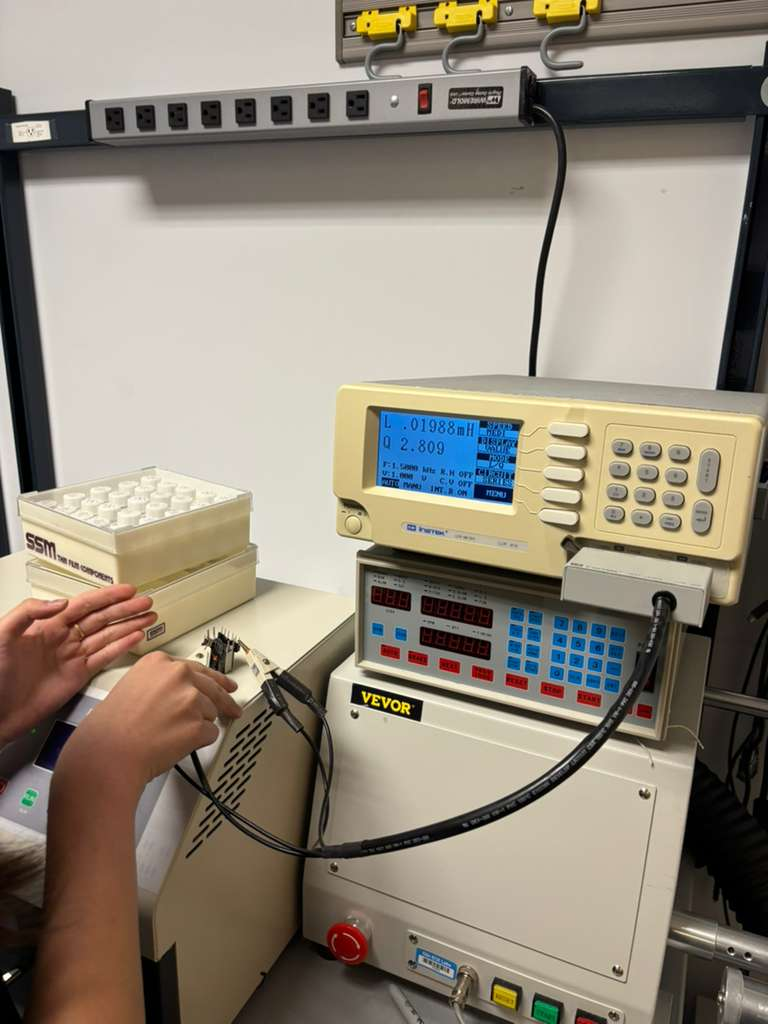

Our wrapped inductor:
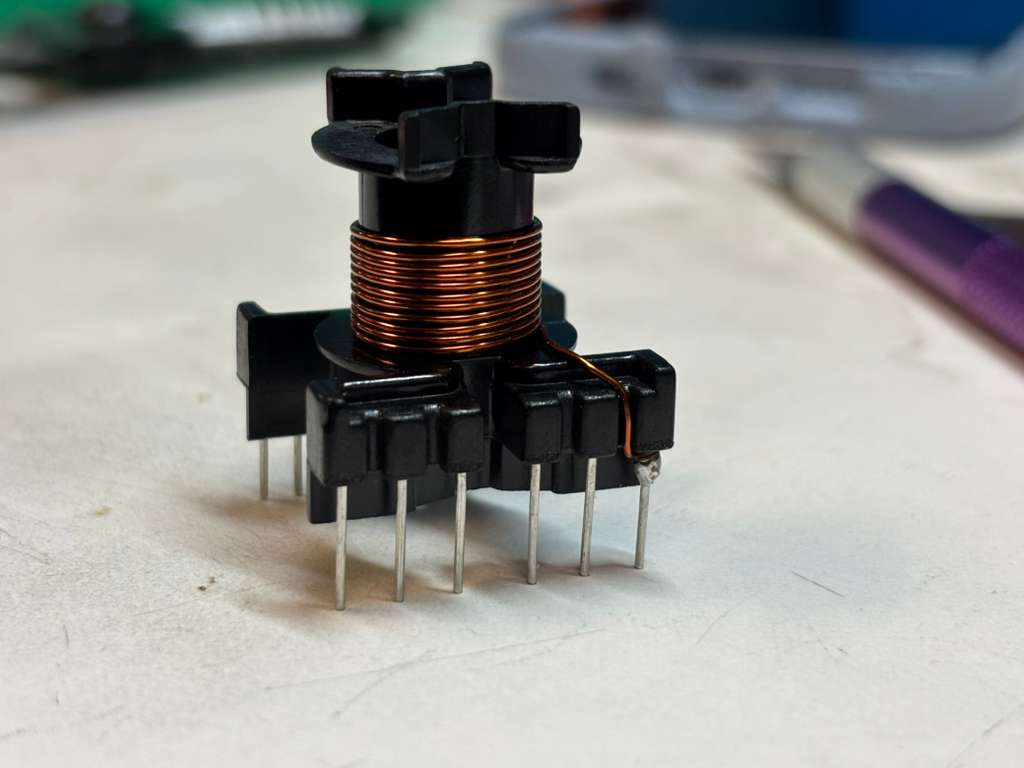

Our fully assembled inductor:

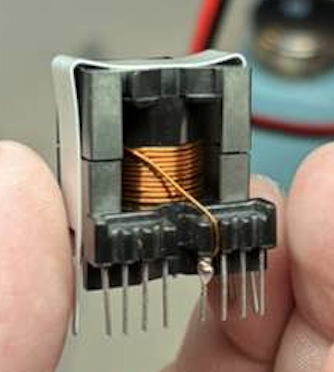

In [6]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
pd.set_option('display.float_format', lambda x: '%e' % x)

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

### Q1, Q2, Q3: 100mV Vsh Peak

Measured Voltage Output: 3.291V

Measured Current Output: 0.18A

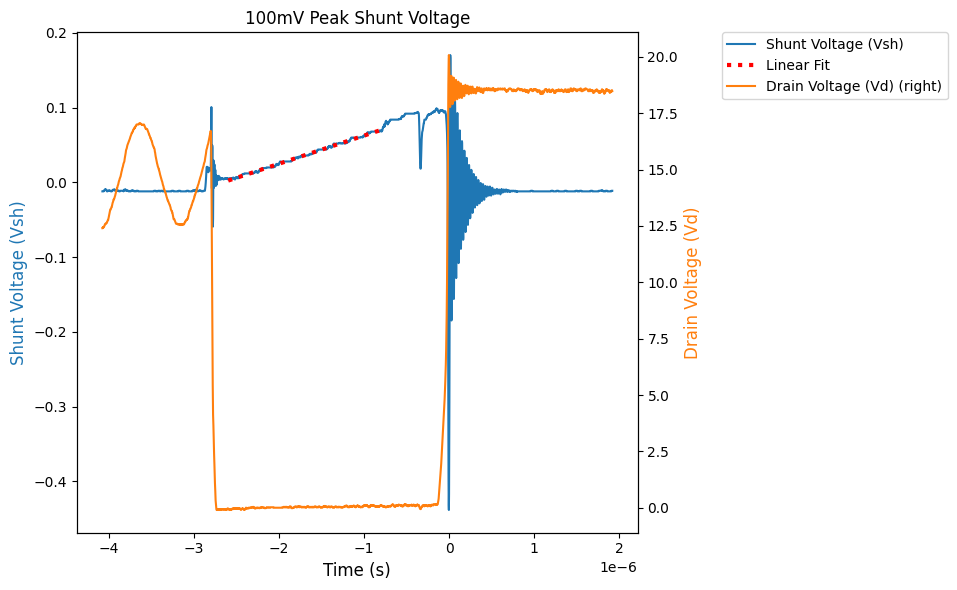

The di/dt value for the linear fit is 753439.7450A/s
The measured inductance value is 19.4936uH


In [7]:
def plot_lab4(filepath, x1, x2, Vout, title): 
    [data, t0, dT] = read_rigol_csv(filepath)
    fig, ax = plt.subplots(figsize=(10, 6))
    data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
    data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
    data.plot(x="X", y="CH1", ax=ax, label="Shunt Voltage (Vsh)", legend=False, color='tab:blue')
    ax2 = data.plot(x="X", y="CH2", ax=ax, secondary_y=True, label="Drain Voltage (Vd)", legend=False, color='tab:orange')
    
    subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
    result = linregress(subset['X'], subset['CH1'])
    slope = result.slope
    
    fit = slope * subset['X'] + result.intercept
    
    ax.plot(subset['X'], fit, color="red", linewidth=3, linestyle="dotted", label='Linear Fit')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, 
               loc='upper left', 
               bbox_to_anchor=(1.15, 1.0), 
               borderaxespad=0.)
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("Shunt Voltage (Vsh)", fontsize=12, color='tab:blue')
    ax2.set_ylabel("Drain Voltage (Vd)", fontsize=12, color='tab:orange')
    
    plt.title(title+" Peak Shunt Voltage")
    plt.tight_layout()
    plt.show()
    
    Avg_Vd = np.mean(subset['CH2'])
    
    # Vg = Vout + Avg_Vd + Vind
    Vind = Vg - Vout - Avg_Vd
    di_dt = slope/R_SH
    L = Vind/di_dt
    print(f"The di/dt value for the linear fit is {di_dt:.4f}A/s")
    print(f"The measured inductance value is {L*1e6:.4f}uH")
    return Vind, L
params_100mv = ("data/100mV.csv", -2.6e-6, -0.8e-6, 3.291, "100mV")
Vind_100mV, L_100mV = plot_lab4(*params_100mv)

### Q4, Q5, Q6: 200mV Vsh Peak

Measured Voltage Output: 7.51V

Measured Current Output: 0.73A

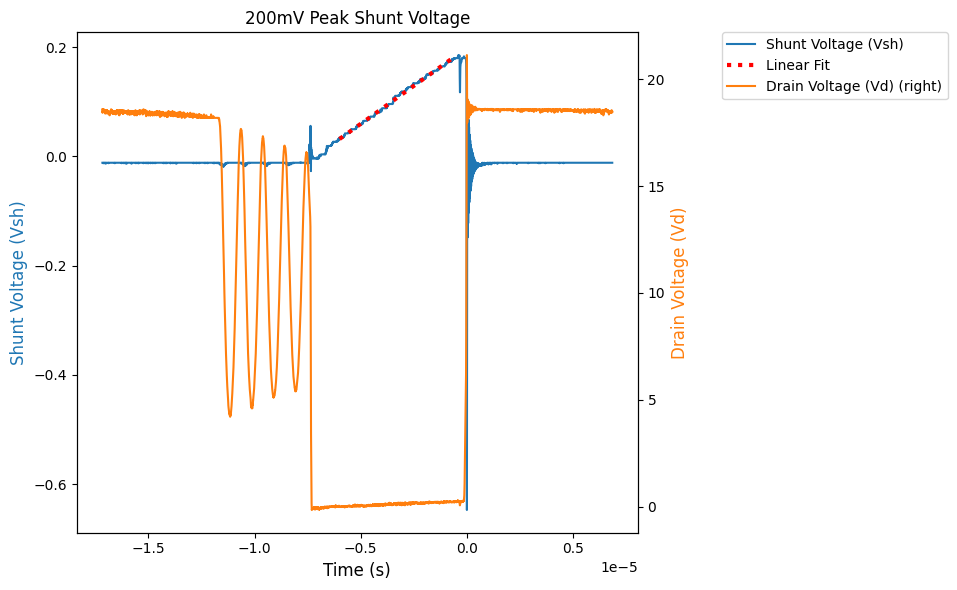

The di/dt value for the linear fit is 556272.1360A/s
The measured inductance value is 18.6541uH


In [12]:
params_200mv = ("data/200mV.csv", -0.6e-5, -0.07e-5, 7.51, "200mV")
Vind_200mV, L_200mV = plot_lab4(*params_200mv)

In [9]:
# Average measured inductance
print(f"Average measured inductance: {(L_100mV + L_200mV)/2*1e6:.3f}uH")

Average measured inductance: 7.490uH


### Q7: Document adjustments made and experimental findings.
No adjustments were necessary, since our inductor was found to be between 18.65uH and 19.49uH, both of which are within the 20uH +0%/-20% range listed. Additionally, Beat told us we did not need to re-wind our inductor with 20AWG wire.

### Q8: Analyze the potential causes for why the initial design did not meet the desired specifications.

In [10]:
I_rms = math.sqrt(1/3) * I_PK # boundary conduction mode
for awg, area in awg_to_wire_area.items():
    J_max = I_rms / area
    print(f"{awg} AWG Current Density (J): {J_max:.2f} A/mm^2\n")

18 AWG Current Density (J): 4.21 A/mm^2

20 AWG Current Density (J): 6.69 A/mm^2

22 AWG Current Density (J): 10.63 A/mm^2

24 AWG Current Density (J): 16.90 A/mm^2



The initial design did not meet the maximal RMS current density specification of 10 A_rms/mm^2 because with a 24 AWG, the calculated A_rms/mm^2 is 16.90 A_rms/mm^2 in BCM. An improved design would be with 20 AWG with the same number of turns (11), which has a max current density of 6.69 A_rms/mm^2 in BCM. However, it did meet all other specifications.

### Q9: Produce a final drawing for inductor that meets the required specifications.

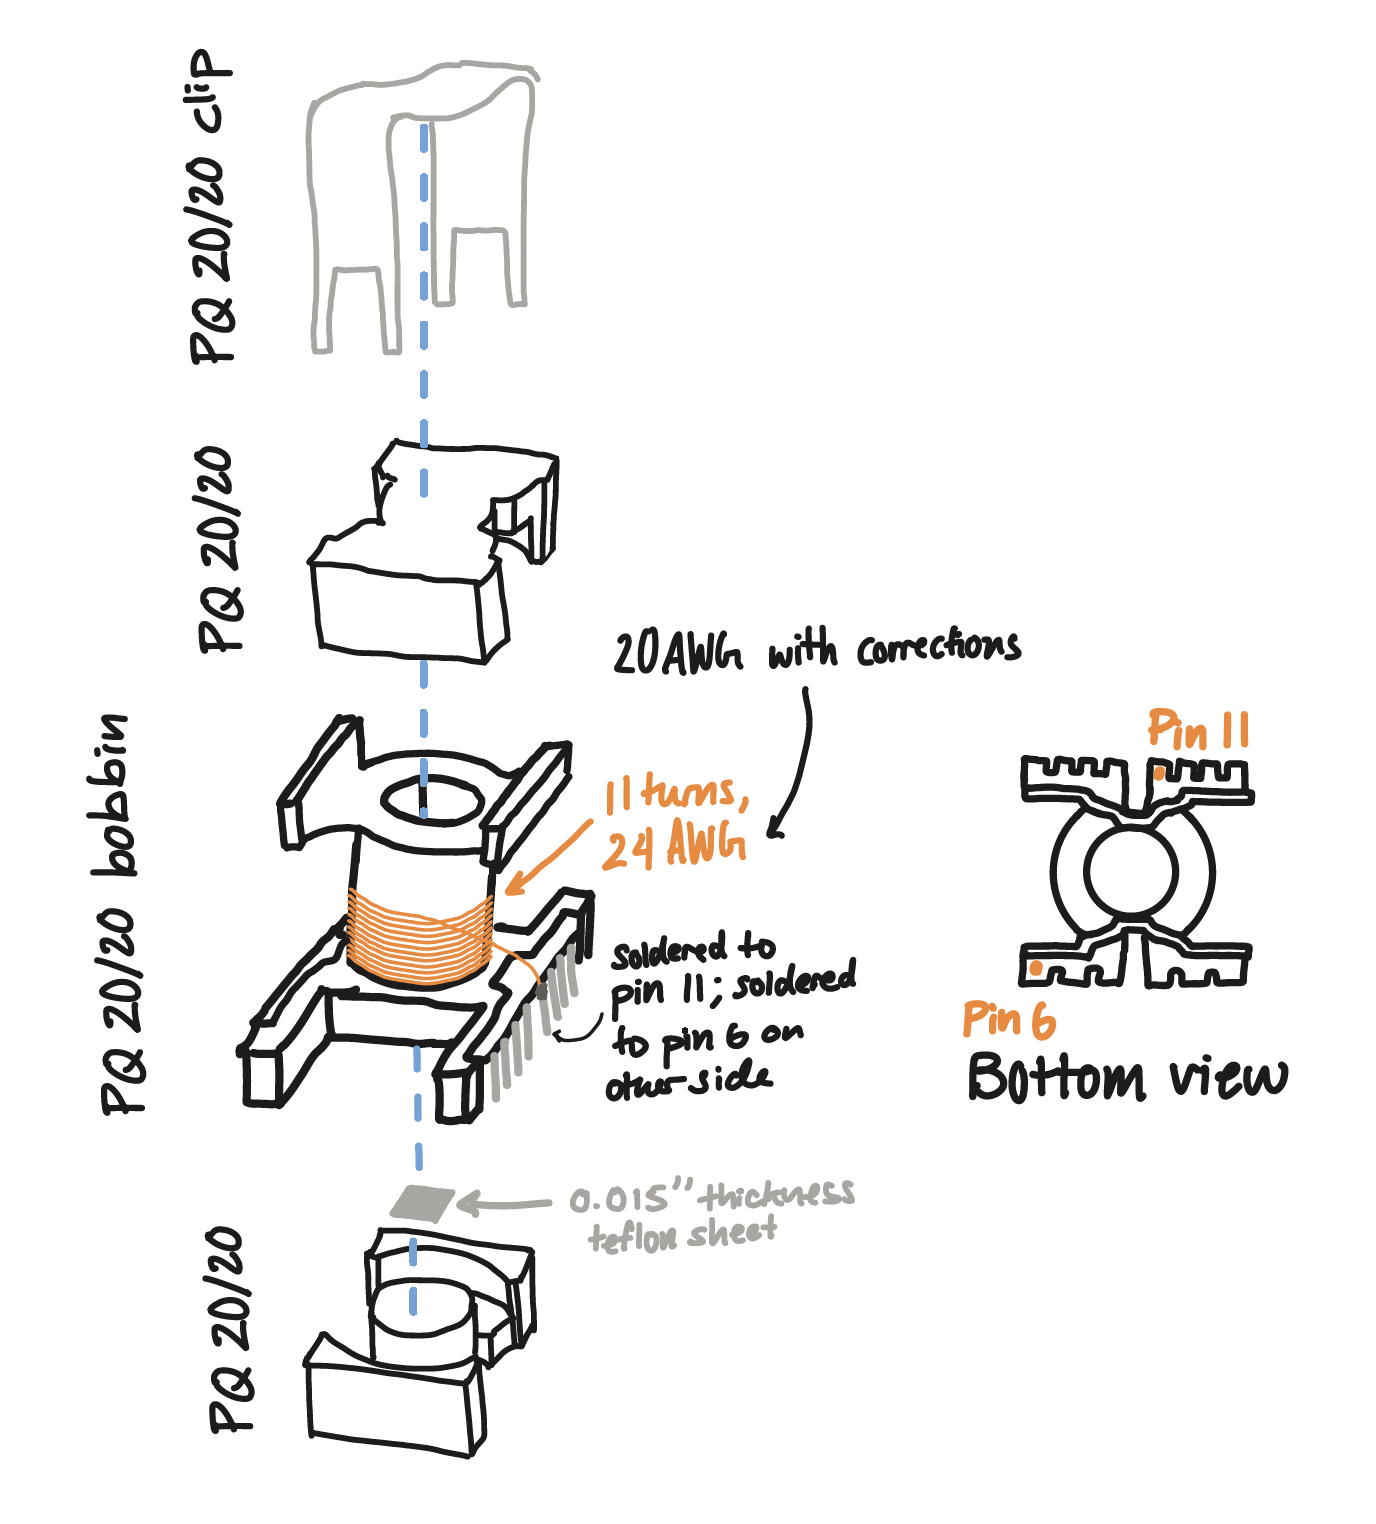

### Q10: Update digital twin with actual inductance value, simulate the test operating conditions and compare measured with simulated waveforms.

#### 100mV Shunt Voltage Peak Plot:
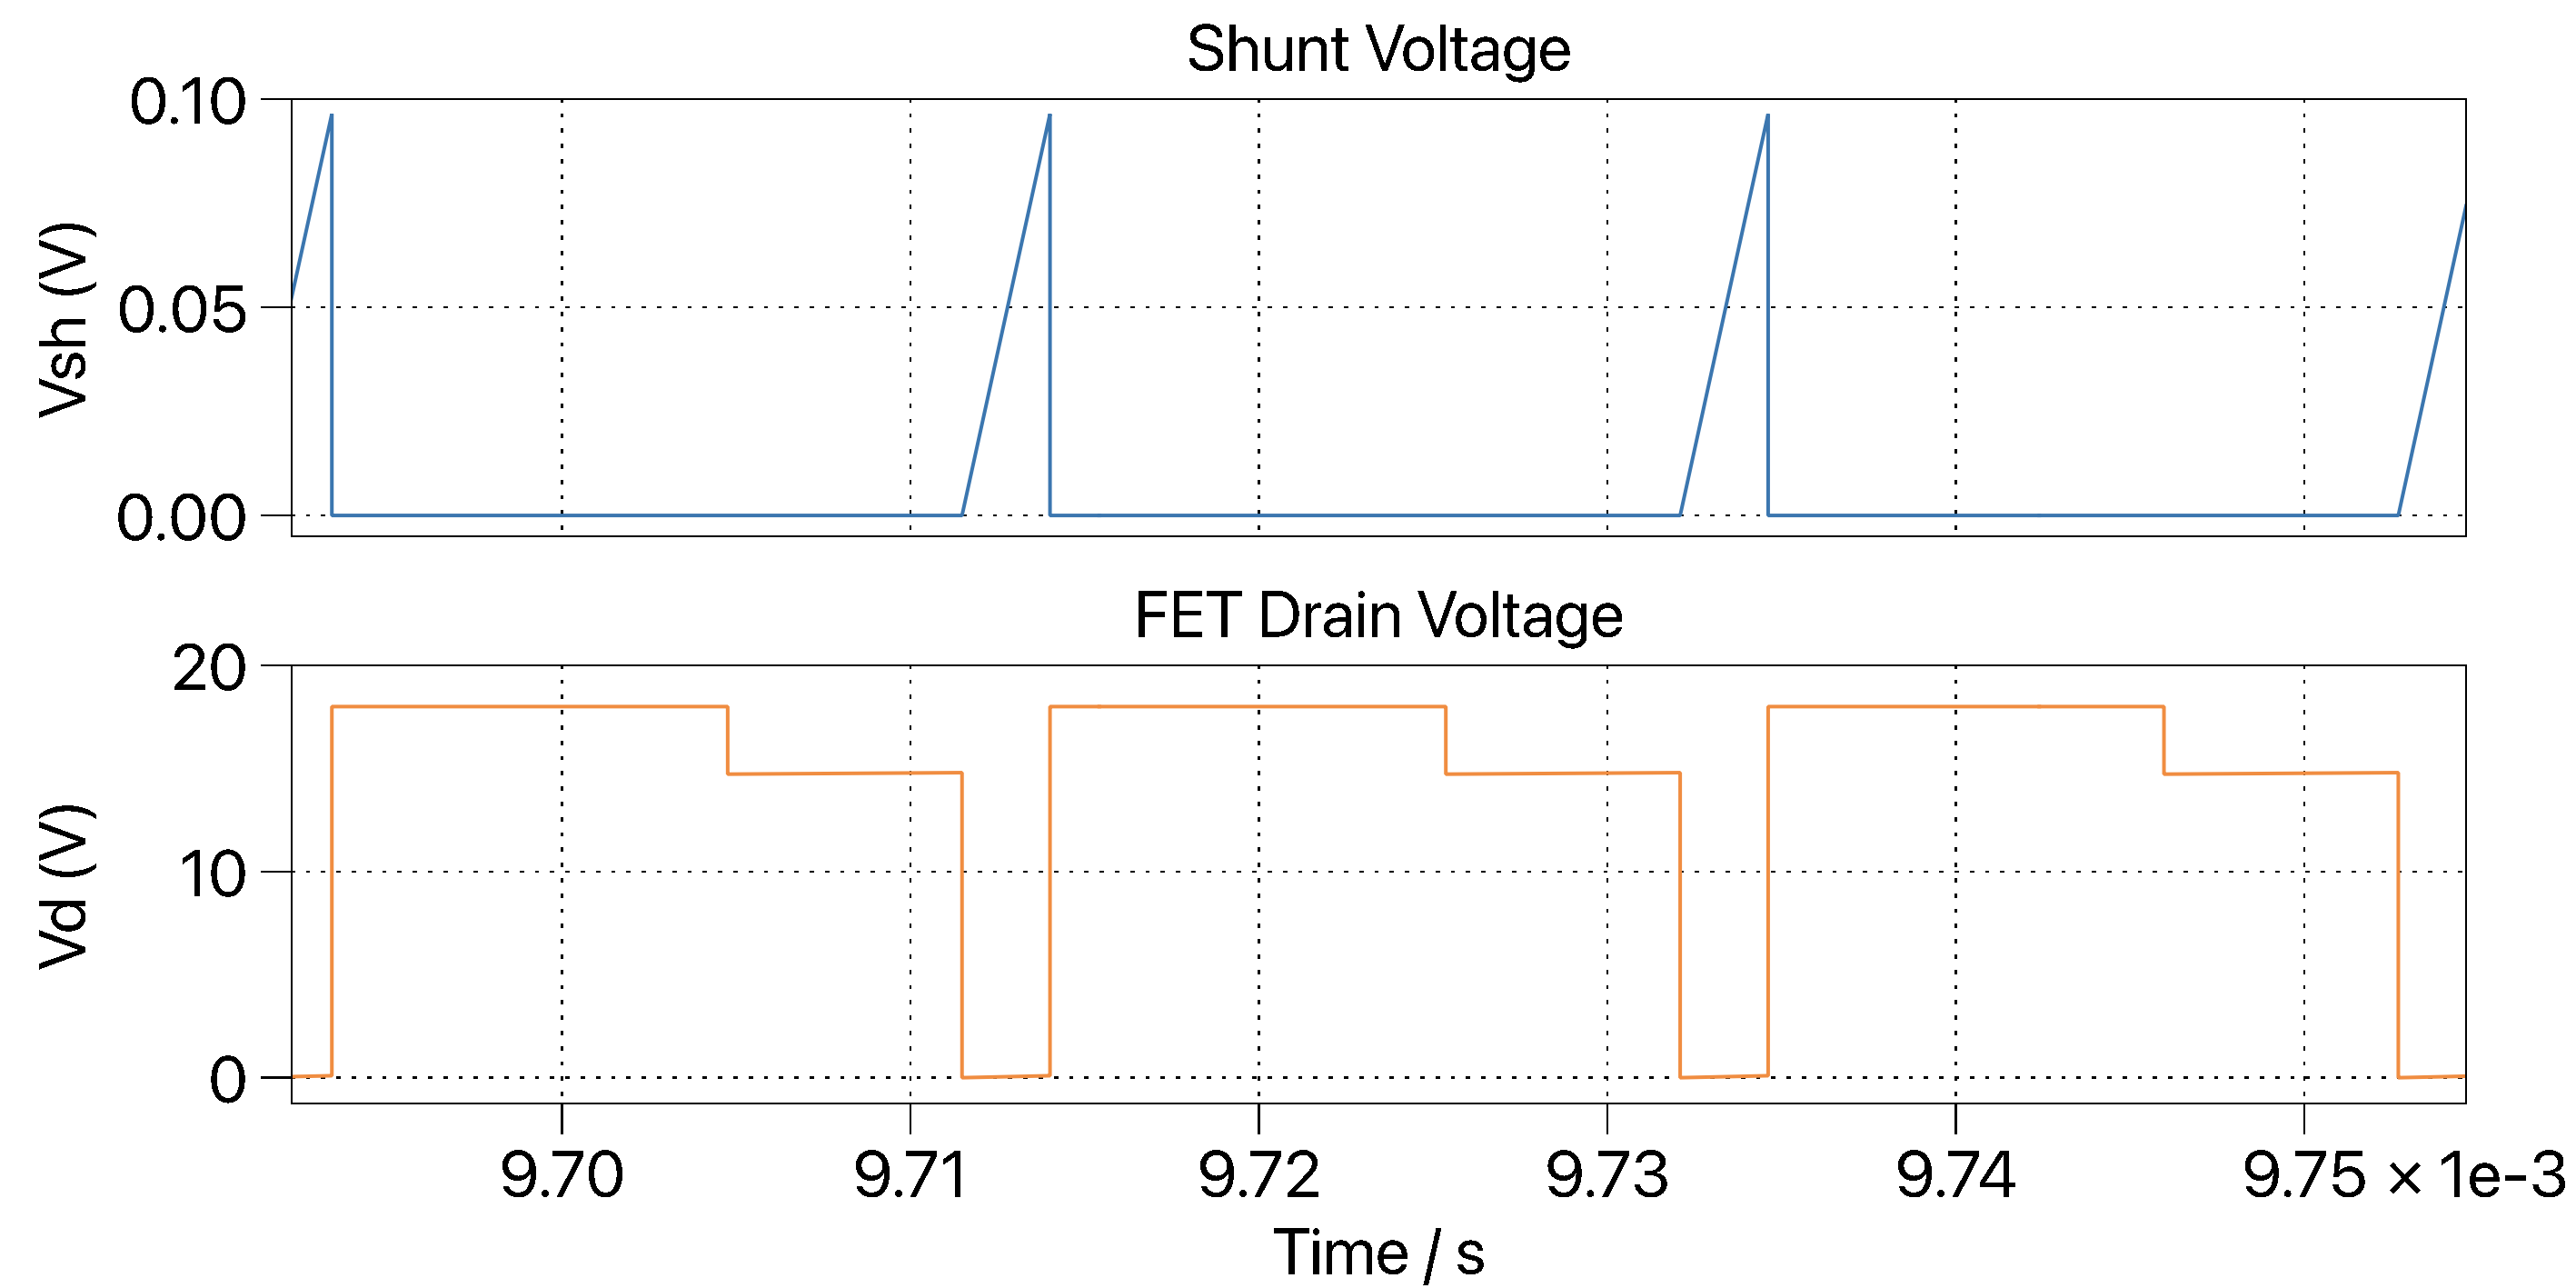

#### 200mV Shunt Voltage Peak Plot:
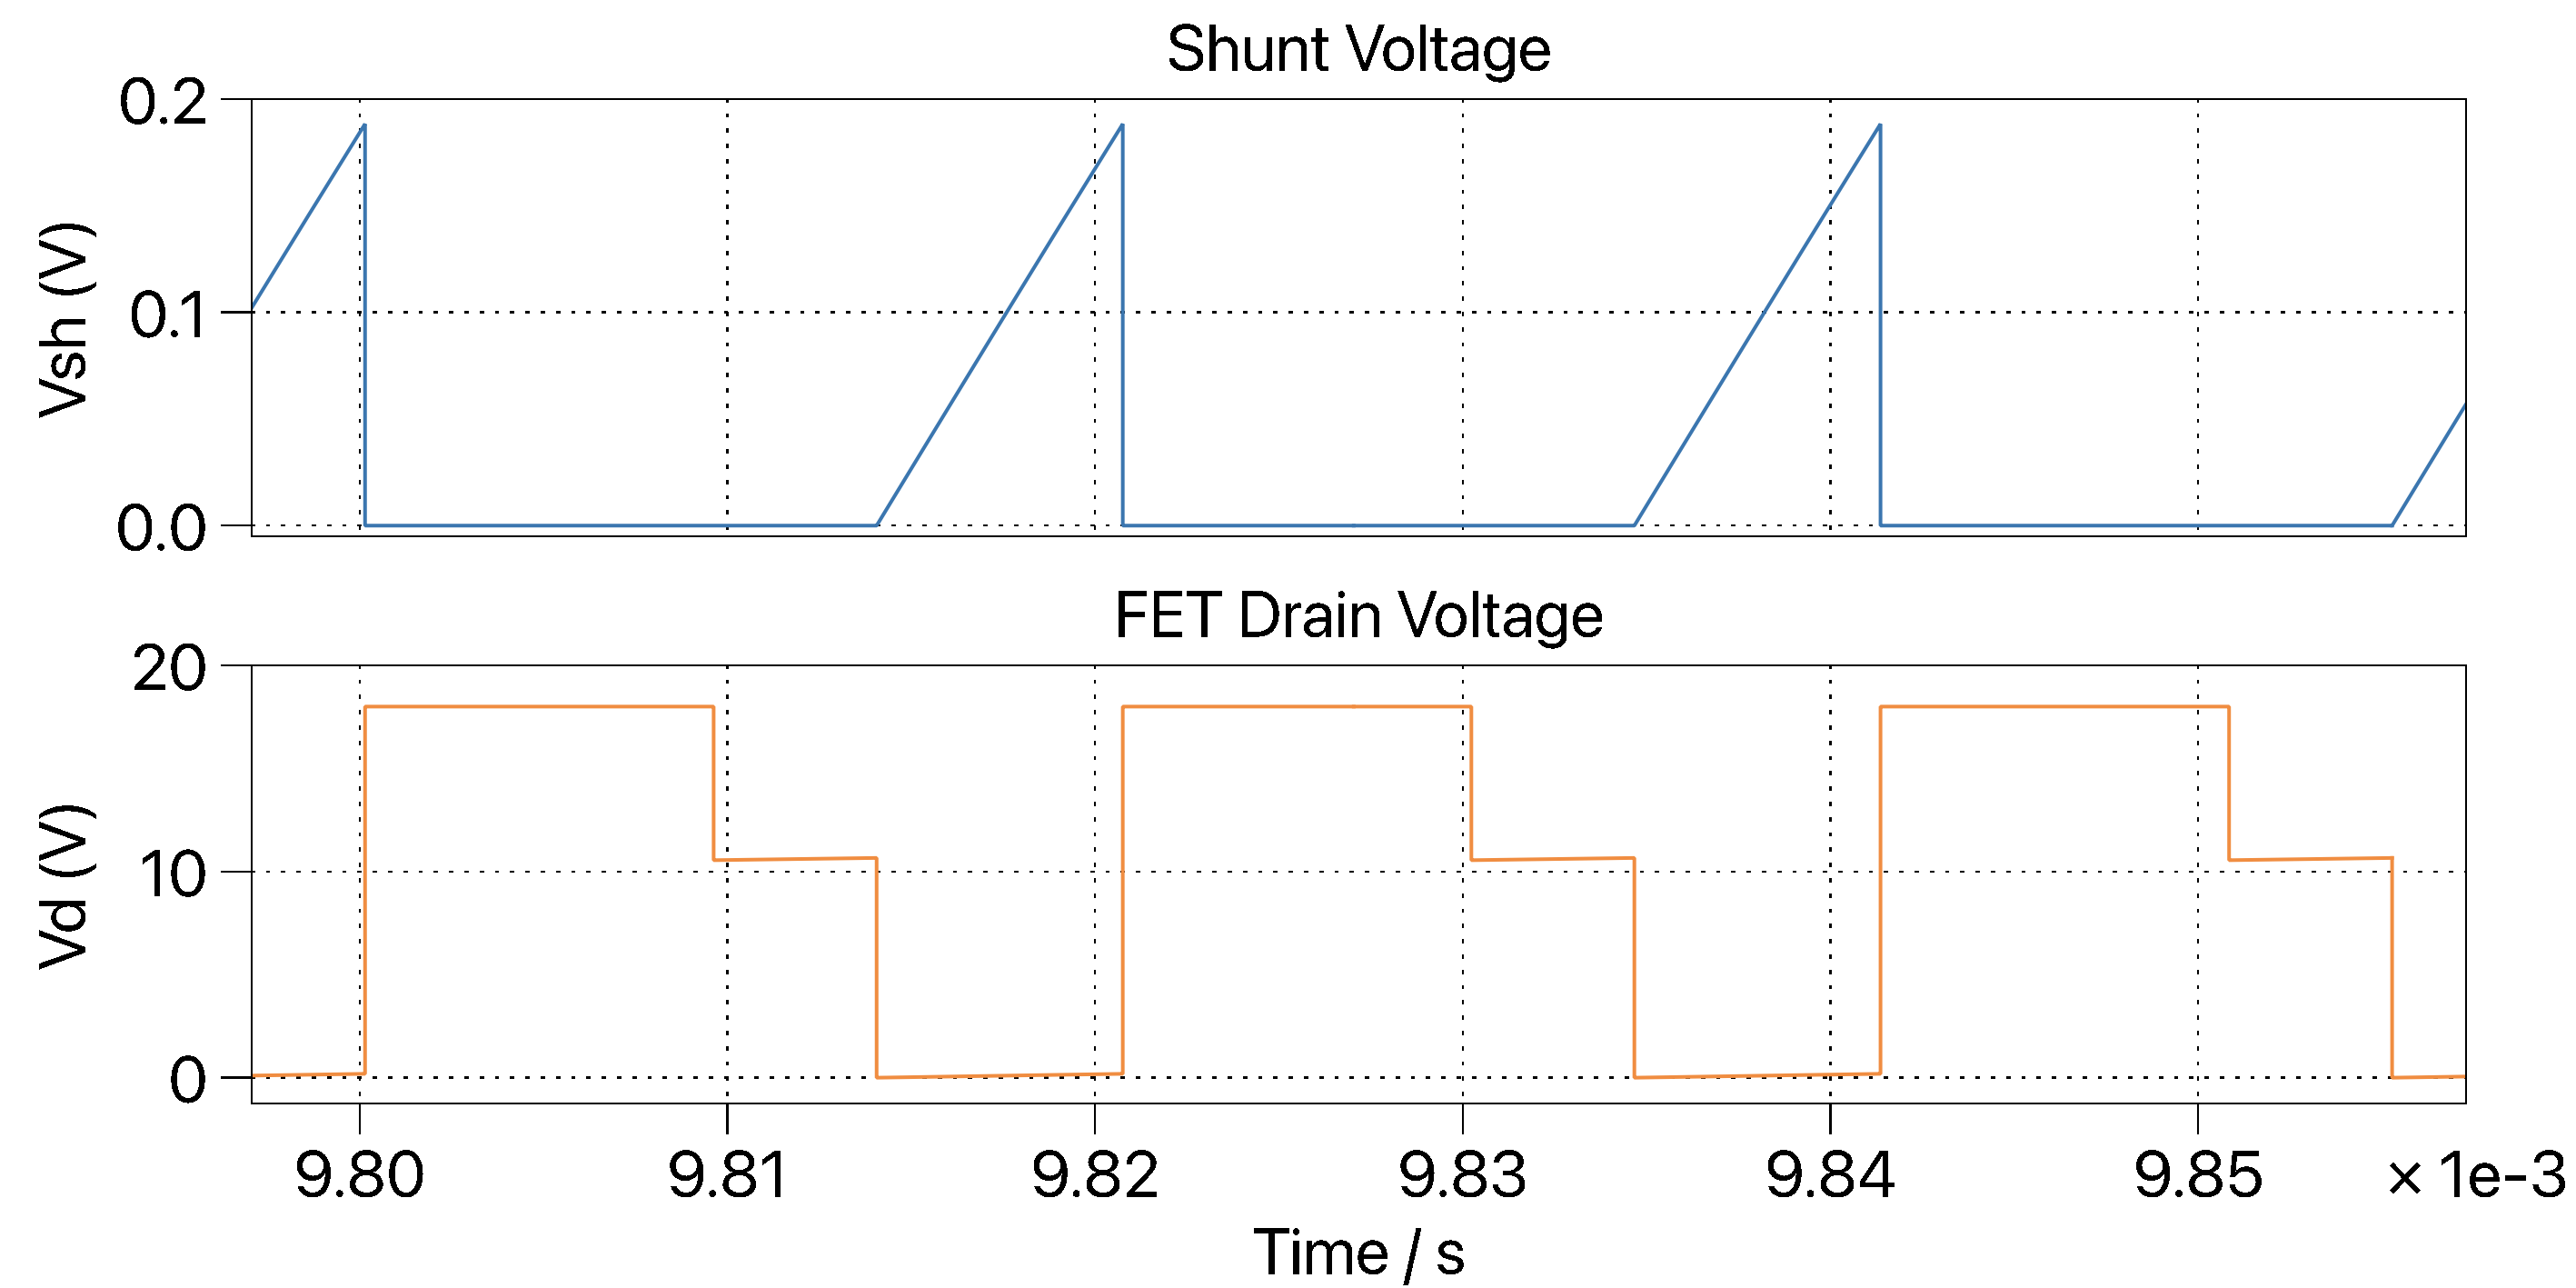


The 100mV Vsh peak plot in both simulation and reality have a higher
di/dt than the 200mV Vsh peak plots, which makes sense because the 
potentiometer value is a way to control the duty cycle.

The following is pretty much the same as what I had to say about Lab 3's
simulation vs reality, since these observations still hold.

The waveforms of the shunt and drain voltages follow a similar shape to
the actual measured values, but the measured output has many more real-world
effects. The most evident of these are the ringing that occurs in the Vdrain
when the voltage switches to a different level, the two spikes in shunt voltage 
that happen when the MOSFET opens or closes, in this case more evident in the
100mV data than in the 200mV data, and the ringing visible in Vdrain 
when the MOSFET closes.

Similiarities between the two are that the max FET drain voltage reaches 18V
in simulation and the real data also has a long on section at 18V, although
there is a small spike right before it when the MOSFET is switching. Both
datasets also have a step down from the main voltage of 18V to a lower voltage,
although the measured dataset has an oscillating pattern around that value
instead of a clean drop to the lower value.

Both simulation and real data have the same frequency across all voltages, 
which makes sense since I set the simulation to have that frequency and 
frequency is constant regardless of output voltage, since it's determined 
by the chip.

### Q11: Use your measurements to plot the Lambda [Vs] versus Current [A] characteristic of your inductor. You will need to integrate the voltage measurement to obtain Lambda.

$$
\begin{aligned}
L \cdot i &= \lambda \\
\text{Since } V_{ind} &= L \cdot \frac{di}{dt} \\
V_{ind} &= \frac{d\lambda}{dt} \\
\lambda &= \int V_{ind}(t) \,dt
\end{aligned}
$$

We also know that the inductor voltage is only readable by the shunt resistor when the MOSFET is closed, since when the FET opens the shunt resistor is no longer connected to the inductor. Thus, we can only integrate over the time period in which the MOSFET is closed to plot $\lambda$.

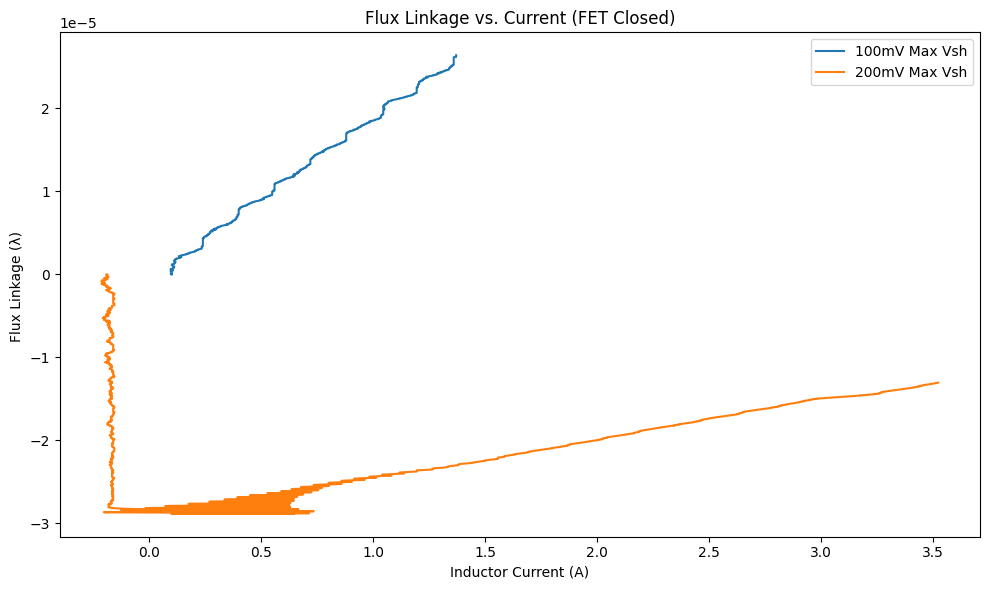

In [11]:
from scipy.integrate import cumulative_trapezoid

fig, ax = plt.subplots(figsize=(10, 6))

def plot_flux_linkage(filepath, x1, x2, Vout, title):
    [data, t0, dT] = read_rigol_csv(filepath)
    data['CH1'] = data['CH1'].rolling(30, min_periods=1).mean() # Vshunt
    data['CH2'] = data['CH2'].rolling(30, min_periods=1).mean() # Vdrain

    data = data[(data['X'] >= x1) & (data['X'] <= x2)] # slicing relevant part 
    
    # I = Vshunt / R_SH
    data['I'] = data['CH1'] / R_SH
    
    # Vg = Vout + Vd + V_ind
    data['V_ind'] = (Vg - Vout - data['CH2']).fillna(0)

    data['flux linkage'] = cumulative_trapezoid(data['V_ind'], data['X'], initial=0)

    ax.plot(data['I'], data['flux linkage'], label=title + " Max Vsh")

plot_flux_linkage(*params_100mv)
plot_flux_linkage(*params_200mv)

ax.set_title("Flux Linkage vs. Current (FET Closed)")
ax.set_xlabel("Inductor Current (A)")
ax.set_ylabel("Flux Linkage (λ) ")
ax.legend()

fig.tight_layout()
plt.show()

### Independent Steps
1. I made a compilation of all the relevant equations from the course so far pertaining to buck converters by category as a sort of short-hand cheatsheet. This helped me synthesize the relationships between different lessons in the course a lot since it literally gives you a high level overview of what equations relate the different measurements we have been looking at throughout the course. It's especially helpful for discerning the difference between CCM, DCM, and BCM behavior at a glance.
2. I provided reference code for Allan for the inductor measurement extraction method, which he converted to matlab, and explained the relationship between inductor voltage and the other voltages (essentially the Vg = Vout + Avg_Vd + Vind thing)
3. I watched this super relevant [video](https://www.youtube.com/watch?v=PEme07iCH-s) which talks about building an inductor, doing all of the calculations to properly create an inductor, saturation and what that means on a magnetic dipole scale, different types of core shapes and their benefits, a few rules of thumb about maximum flux density depending on your cooling mechanism, and ferrite performance's interesting relationship with temperature (90C is ideal). Would recommend including it in your Lab 4 prep as a primer!